In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/NB1_baseline_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/__results__.html
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/NB1_tuned_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/NB1_comparison_results.csv
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/__notebook__.ipynb
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/__output__.json
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/custom.css
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/__results___files/__results___14_0.png
/kaggle/input/notebooks/aissatousamb/mod-lisations-bs1/__results___files/__results___21_2.png
/kaggle/input/notebooks/aissatousamb/eda-tweets/__results__.html
/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv
/kaggle/input/notebooks/aissatousamb/eda-tweets/__notebook__.ipynb
/kaggle/input/notebooks/aissatousamb/eda-tweets/__output__.json
/kaggle/input/notebooks/aiss

# NB3 — Naive Bayes complet, SGD variantes et features numériques

## Contexte

Ce notebook fait suite à NB1 (baselines Count + TF-IDF Word) et NB2
(Char + Hybrid). On explore ici trois nouvelles directions :

1. **Naive Bayes complet** : tester toutes les variantes de Naive Bayes
   (MultinomialNB, BernoulliNB, ComplementNB) avec différentes
   vectorisations pour identifier la meilleure combinaison NB
2. **SGD variantes** : explorer les différentes fonctions de perte du
   SGDClassifier (hinge, modified_huber) qui n'ont pas encore été testées
3. **Features numériques** : intégrer les features numériques créées lors
   du preprocessing (word_count, hashtag_count,...) en complément du
   TF-IDF — pour voir si elles apportent une information supplémentaire

---

## Scores de référence

| Notebook | Meilleur pipeline | F1 classe 1 |
|---|---|---|
| NB1 | P03_TFIDF_UniBi_LogReg | 0.710 |
| NB2 | (à compléter après NB2) | - |

---

## Nouvelles approches testées

### 1. Naive Bayes complet
On teste les trois variantes de Naive Bayes avec CountVectorizer
(brut et binaire) et TF-IDF :

* **MultinomialNB** : conçu pour les données de comptage — chaque
  dimension du vecteur représente une fréquence de mot
* **BernoulliNB** : conçu pour les données binaires — chaque dimension
  indique si un mot est présent (1) ou absent (0), peu importe combien
  de fois
* **ComplementNB** : variante de MultinomialNB qui calcule la probabilité
  qu'un document **n'appartienne pas** à chaque classe — particulièrement
  efficace sur les datasets déséquilibrés comme le nôtre (81/19)

### 2. SGD variantes
Le `SGDClassifier` peut imiter différents modèles selon sa fonction
de perte (`loss`) :

* **`hinge`** : équivalent à un LinearSVC — trouve la frontière qui
  maximise la marge entre les classes. Ne produit pas de probabilités.
* **`modified_huber`** : variante robuste qui produit des probabilités —
  bon compromis entre la robustesse de hinge et la capacité probabiliste
  de log_loss

### 3. Features numériques combinées au TF-IDF
Les features numériques (word_count, mean_word_length, lexical_diversity,
stop_word_count, url_count, punctuation_count, hashtag_count,
keyword_disaster_rate) capturent des caractéristiques **structurelles**
des tweets indépendamment de leur contenu textuel.

On les combine au TF-IDF via `FeatureUnion` :
text_lemma

↓ TF-IDF Word

[features_tfidf]

+               → FeatureUnion → [features_tfidf | features_num]

features_numériques

↓ StandardScaler

[features_scaled]
**Pourquoi StandardScaler ?**
Les features numériques ont des échelles très différentes
(word_count ∈ [1,32], lexical_diversity ∈ [0.2,1.0],...). Sans
normalisation, les features avec de grandes valeurs domineraient le
modèle. StandardScaler centre et réduit chaque feature :
x_scaled = (x - moyenne) / écart_type

→ toutes les features ont moyenne=0 et écart_type=1
---

## Pipelines testés (P11 à P15)

| Pipeline | Vectorisation | Classifieur | Particularité |
|---|---|---|---|
| P11 | Count binaire | BernoulliNB | Présence/absence |
| P12 | Count | ComplementNB | NB + Count + déséquilibre |
| P13 | TF-IDF Word | SGD Hinge | Équivalent LinearSVC |
| P14 | TF-IDF Word | SGD ModHuber | Probabiliste |
| P15 | TF-IDF Word + Features num | LogReg | Texte + structure |

---

## Validation

Même protocole que NB1 et NB2 : **GridSearchCV avec Stratified
K-Fold (5 folds)**, métrique principale = **F1 classe 1**.

In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from collections import OrderedDict

from sklearn.pipeline import Pipeline, FeatureUnion    # enchaînement et combinaison de transformeurs
from sklearn.feature_extraction.text import (
    TfidfVectorizer,    # pondération TF-IDF
    CountVectorizer     # comptage brut
)
from sklearn.naive_bayes import (
    MultinomialNB,    # NB pour données de comptage
    BernoulliNB,      # NB pour données binaires (présence/absence)
    ComplementNB      # NB adapté aux datasets déséquilibrés
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler     # normalisation des features numériques
from sklearn.base import BaseEstimator, TransformerMixin  # pour créer un transformeur custom

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

warnings.filterwarnings('ignore')
print('✅ Imports effectués avec succès')

✅ Imports effectués avec succès


## Chargement des données

On charge les mêmes datasets nettoyés. Les scores de référence à
battre sont ceux de NB1 (F1=0.710) et NB2 (à compléter).

In [3]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TEXT_COL     = 'text_lemma'
LABEL_COL    = 'target'
RANDOM_STATE = 42
REFERENCE_F1 = 0.710   # meilleur score NB1 — à mettre à jour après NB2

FEATURES_NUM = [
    'word_count', 'mean_word_length', 'lexical_diversity',
    'stop_word_count', 'url_count', 'punctuation_count',
    'hashtag_count', 'keyword_disaster_rate'
]

# ── CHARGEMENT DES DONNÉES ────────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/test_cleaned.csv')

# Remplacement des NaN
train['text_lemma'] = train['text_lemma'].fillna('')
test['text_lemma']  = test['text_lemma'].fillna('')

# Définition de X et y (texte)
X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]
y_train = train[LABEL_COL]
y_test  = test[LABEL_COL]

# Définition des features numériques
X_num_train = train[FEATURES_NUM].fillna(0)
X_num_test  = test[FEATURES_NUM].fillna(0)

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")
print(f"Features numériques : {FEATURES_NUM}")
print(f"\n🎯 Score de référence à battre : F1 classe 1 = {REFERENCE_F1}")

Taille train : 8979
Taille test  : 2245
Features numériques : ['word_count', 'mean_word_length', 'lexical_diversity', 'stop_word_count', 'url_count', 'punctuation_count', 'hashtag_count', 'keyword_disaster_rate']

🎯 Score de référence à battre : F1 classe 1 = 0.71


## Transformeur custom pour les features numériques

Pour intégrer les features numériques dans un pipeline sklearn, on
crée un **transformeur custom** — une classe qui extrait les colonnes
numériques du DataFrame et les retourne sous forme de matrice numpy.

`FeatureUnion` attend des transformeurs qui implémentent `fit` et
`transform` — notre classe `NumericFeatureExtractor` fait exactement ça.

In [4]:
# ── TRANSFORMEUR CUSTOM POUR FEATURES NUMÉRIQUES ─────────────────────────────
class NumericFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Transformeur custom qui extrait les features numériques d'un DataFrame.
    Nécessaire pour intégrer les features numériques dans un Pipeline sklearn
    via FeatureUnion, qui attend des objets avec les méthodes fit() et transform().
    """
    def __init__(self, features):
        self.features = features  # liste des colonnes numériques à extraire

    def fit(self, X, y=None):
        return self  # rien à apprendre, on retourne self

    def transform(self, X, y=None):
        # Retourne les colonnes numériques sous forme de matrice numpy
        return X[self.features].fillna(0).values


print("✅ Transformeur NumericFeatureExtractor défini")

✅ Transformeur NumericFeatureExtractor défini


## Définition des pipelines

**Note importante pour P15 (TF-IDF + Features numériques) :**
Ce pipeline reçoit le DataFrame complet (texte + features numériques)
et non juste la colonne texte. `FeatureUnion` applique en parallèle :
- `TfidfVectorizer` sur la colonne `text_lemma`
- `NumericFeatureExtractor` + `StandardScaler` sur les features numériques

Pour que `TfidfVectorizer` puisse extraire la colonne texte depuis
le DataFrame, on utilise une lambda dans un `FunctionTransformer`.

In [5]:
# ── DÉFINITION DES PIPELINES P11 À P15 ───────────────────────────────────────
from sklearn.preprocessing import FunctionTransformer  # applique une fonction comme transformeur

# Fonctions d'extraction 
get_text    = FunctionTransformer(lambda X: X[TEXT_COL], validate=False)
get_numeric = FunctionTransformer(lambda X: X[FEATURES_NUM].fillna(0), validate=False)

pipelines = OrderedDict({

    # P11 : CountVectorizer binaire + BernoulliNB
    "P11_CountBin_BernoulliNB": Pipeline([
        ("vect", CountVectorizer(binary=True, ngram_range=(1,2), min_df=2, max_df=0.95)),
        ("clf",  BernoulliNB())
    ]),

    # P12 : CountVectorizer + ComplementNB
    "P12_Count_ComplementNB": Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
        ("clf",  ComplementNB())
    ]),

    # P13 : TF-IDF Word + SGD Hinge
    "P13_TFIDF_Word_SGD_Hinge": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ("clf",  SGDClassifier(loss='hinge', penalty='l2', alpha=1e-5,
                               max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # P14 : TF-IDF Word + SGD Modified Huber
    "P14_TFIDF_Word_SGD_ModHuber": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ("clf",  SGDClassifier(loss='modified_huber', penalty='l2', alpha=1e-5,
                               max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # P15 : TF-IDF Word + Features numériques + LogReg
    "P15_TFIDF_Num_LogReg": Pipeline([
        ("features", FeatureUnion([
            ("tfidf", Pipeline([
                ("extract_text", get_text),
                ("tfidf_vect",   TfidfVectorizer(ngram_range=(1,2), min_df=2,
                                                  max_df=0.95, sublinear_tf=True))
            ])),
            ("numeric", Pipeline([
                ("extract_num", get_numeric),
                ("scale",        StandardScaler())
            ]))
        ])),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
})

print(f"✅ {len(pipelines)} pipelines définis (P11 à P15)")
for name in pipelines:
    print(f"   → {name}")

✅ 5 pipelines définis (P11 à P15)
   → P11_CountBin_BernoulliNB
   → P12_Count_ComplementNB
   → P13_TFIDF_Word_SGD_Hinge
   → P14_TFIDF_Word_SGD_ModHuber
   → P15_TFIDF_Num_LogReg


## Phase 1 — Baselines sans optimisation

**Note pour P15 :** ce pipeline reçoit le DataFrame complet (pas juste
la colonne texte). On adapte donc X_train et X_test pour ce pipeline.

In [6]:
# ── PHASE 1 : BASELINES ───────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — BASELINES SANS OPTIMISATION")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

baseline_results = []

for name, pipeline in pipelines.items():
    print(f"\n→ Entraînement : {name}")

    # P15 reçoit le DataFrame complet (texte + features numériques)
    # Les autres pipelines reçoivent uniquement la colonne texte
    if name == "P15_TFIDF_Num_LogReg":
        X_tr = train[[TEXT_COL] + FEATURES_NUM]
        X_te = test[[TEXT_COL] + FEATURES_NUM]
    else:
        X_tr = X_train
        X_te = X_test

    pipeline.fit(X_tr, y_train)
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test  = pipeline.predict(X_te)

    test_f1 = f1_score(y_test, y_pred_test)
    flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

    baseline_results.append({
        'pipeline'                : name,
        'train_accuracy'          : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'        : f1_score(y_train, y_pred_train),
        'train_recall_class_1'    : recall_score(y_train, y_pred_train),
        'train_precision_class_1' : precision_score(y_train, y_pred_train),
        'test_accuracy'           : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'         : test_f1,
        'test_recall_class_1'     : recall_score(y_test, y_pred_test),
        'test_precision_class_1'  : precision_score(y_test, y_pred_test),
        'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
    })

    print(f"   ✅ F1 classe 1 : {test_f1:.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

baseline_df = pd.DataFrame(baseline_results).round(3)
baseline_df = baseline_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Baseline NB3 ===")
display(baseline_df)

PHASE 1 — BASELINES SANS OPTIMISATION
Score de référence : F1 classe 1 = 0.71

→ Entraînement : P11_CountBin_BernoulliNB
   ✅ F1 classe 1 : 0.619 | Recall : 0.475 | Accuracy : 0.892 | 🔴 En dessous

→ Entraînement : P12_Count_ComplementNB
   ✅ F1 classe 1 : 0.707 | Recall : 0.723 | Accuracy : 0.889 | 🔴 En dessous

→ Entraînement : P13_TFIDF_Word_SGD_Hinge
   ✅ F1 classe 1 : 0.686 | Recall : 0.675 | Accuracy : 0.886 | 🔴 En dessous

→ Entraînement : P14_TFIDF_Word_SGD_ModHuber
   ✅ F1 classe 1 : 0.681 | Recall : 0.675 | Accuracy : 0.883 | 🔴 En dessous

→ Entraînement : P15_TFIDF_Num_LogReg
   ✅ F1 classe 1 : 0.574 | Recall : 0.465 | Accuracy : 0.872 | 🔴 En dessous

=== Tableau comparatif — Phase Baseline NB3 ===


,pipeline,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
1,P12_Count_ComplementNB,0.931,0.824,0.872,0.781,0.889,0.707,0.723,0.691,0.819,0.825
2,P13_TFIDF_Word_SGD_Hinge,0.998,0.995,0.992,0.998,0.886,0.686,0.675,0.698,0.808,0.804
3,P14_TFIDF_Word_SGD_ModHuber,0.998,0.995,0.996,0.995,0.883,0.681,0.675,0.688,0.805,0.803
0,P11_CountBin_BernoulliNB,0.934,0.797,0.695,0.932,0.892,0.619,0.475,0.891,0.778,0.731
4,P15_TFIDF_Num_LogReg,0.910,0.696,0.560,0.921,0.872,0.574,0.465,0.748,0.749,0.715


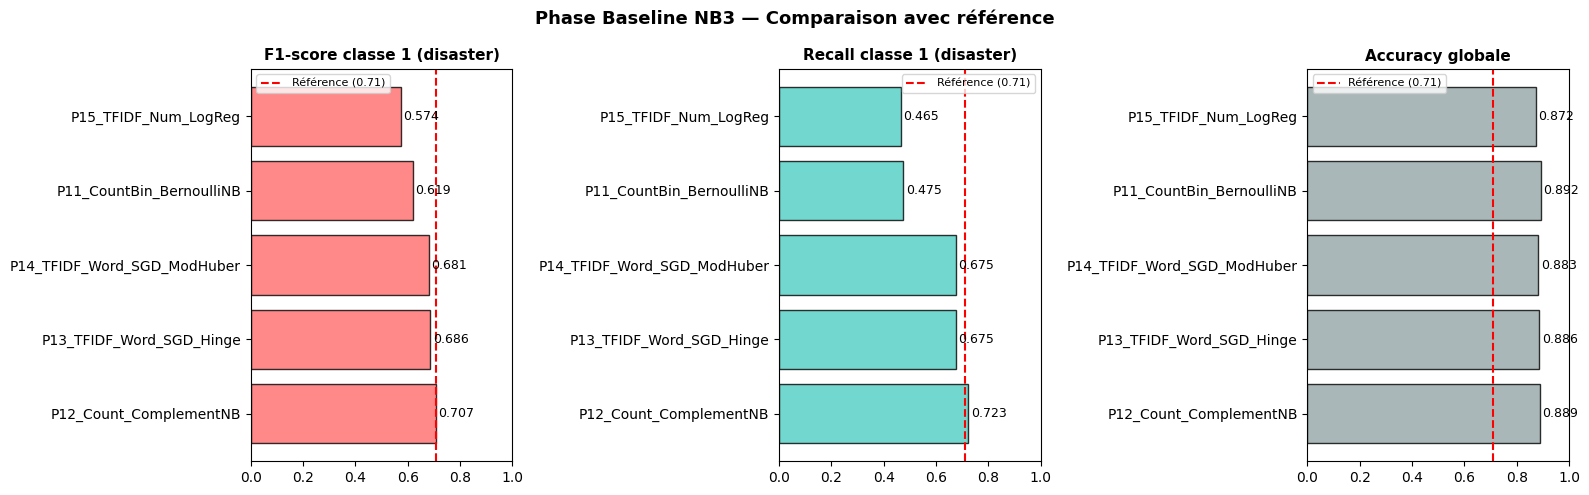

In [7]:
# ── VISUALISATION BASELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_f1_class_1', 'test_recall_class_1', 'test_accuracy']
titles  = ['F1-score classe 1 (disaster)', 'Recall classe 1 (disaster)', 'Accuracy globale']
colors  = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.barh(baseline_df['pipeline'], baseline_df[metric],
                   color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(REFERENCE_F1, color='red', linestyle='--',
               linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, baseline_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase Baseline NB3 — Comparaison avec référence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 — Tuning avec GridSearchCV et K-Fold Stratifié

Même protocole que NB1 et NB2. Pour P15 (features numériques),
le DataFrame complet est passé à GridSearchCV.

In [8]:
# ── GRILLES D'HYPERPARAMÈTRES ─────────────────────────────────────────────────
param_grids = {
    # BernoulliNB : alpha = lissage
    "P11_CountBin_BernoulliNB": {
        "clf__alpha"    : [0.1, 0.5, 1.0, 2.0],
        "clf__binarize" : [0.0, 0.1, 0.5]  # seuil de binarisation
    },

    # ComplementNB : alpha + norm
    "P12_Count_ComplementNB": {
        "clf__alpha": [0.1, 0.5, 1.0, 2.0],
        "clf__norm" : [True, False]
    },

    # SGD Hinge : alpha + class_weight
    "P13_TFIDF_Word_SGD_Hinge": {
        "clf__alpha"       : [1e-6, 1e-5, 1e-4],
        "clf__class_weight": [None, "balanced"],
        "clf__penalty"     : ["l2", "elasticnet"]
    },

    # SGD ModHuber : mêmes hyperparamètres
    "P14_TFIDF_Word_SGD_ModHuber": {
        "clf__alpha"       : [1e-6, 1e-5, 1e-4],
        "clf__class_weight": [None, "balanced"],
        "clf__penalty"     : ["l2", "elasticnet"]
    },

    # LogReg avec features numériques : C + class_weight
    "P15_TFIDF_Num_LogReg": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },
}

print("✅ Grilles d'hyperparamètres définies")
for name, grid in param_grids.items():
    n_combinations = 1
    for values in grid.values():
        n_combinations *= len(values)
    print(f"   → {name} : {n_combinations} combinaisons × 5 folds = "
          f"{n_combinations * 5} entraînements")

✅ Grilles d'hyperparamètres définies
   → P11_CountBin_BernoulliNB : 12 combinaisons × 5 folds = 60 entraînements
   → P12_Count_ComplementNB : 8 combinaisons × 5 folds = 40 entraînements
   → P13_TFIDF_Word_SGD_Hinge : 12 combinaisons × 5 folds = 60 entraînements
   → P14_TFIDF_Word_SGD_ModHuber : 12 combinaisons × 5 folds = 60 entraînements
   → P15_TFIDF_Num_LogReg : 10 combinaisons × 5 folds = 50 entraînements


In [9]:
# ── PHASE 2 : GRIDSEARCHCV + K-FOLD ──────────────────────────────────────────
print("=" * 70)
print("PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_results = []

for name, pipeline in pipelines.items():
    print(f"\n{'='*70}")
    print(f"Tuning → {name}")

    param_grid = param_grids.get(name)
    if param_grid is None:
        print("Aucune grille définie — pipeline ignoré")
        continue

    # P15 reçoit le DataFrame complet
    if name == "P15_TFIDF_Num_LogReg":
        X_tr = train[[TEXT_COL] + FEATURES_NUM]
        X_te = test[[TEXT_COL] + FEATURES_NUM]
    else:
        X_tr = X_train
        X_te = X_test

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid,
        cv         = cv,
        scoring    = 'f1',
        n_jobs     = -1,
        verbose    = 1
    )

    grid_search.fit(X_tr, y_train)

    print(f"   Meilleurs paramètres : {grid_search.best_params_}")
    print(f"   Meilleur F1 (CV)     : {grid_search.best_score_:.3f}")

    y_pred_train = grid_search.predict(X_tr)
    y_pred_test  = grid_search.predict(X_te)

    test_f1 = f1_score(y_test, y_pred_test)
    flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

    tuned_results.append({
        'pipeline'                : name,
        'best_params'             : json.dumps(grid_search.best_params_),
        'best_cv_f1_class_1'      : grid_search.best_score_,
        'train_accuracy'          : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'        : f1_score(y_train, y_pred_train),
        'train_recall_class_1'    : recall_score(y_train, y_pred_train),
        'train_precision_class_1' : precision_score(y_train, y_pred_train),
        'test_accuracy'           : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'         : test_f1,
        'test_recall_class_1'     : recall_score(y_test, y_pred_test),
        'test_precision_class_1'  : precision_score(y_test, y_pred_test),
        'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
    })

    print(f"   ✅ Test F1 classe 1 : {test_f1:.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

tuned_df = pd.DataFrame(tuned_results).round(3)
tuned_df = tuned_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Tuning NB3 ===")
display(tuned_df)

PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)
Score de référence : F1 classe 1 = 0.71

Tuning → P11_CountBin_BernoulliNB
Fitting 5 folds for each of 12 candidates, totalling 60 fits
   Meilleurs paramètres : {'clf__alpha': 0.1, 'clf__binarize': 0.0}
   Meilleur F1 (CV)     : 0.689
   ✅ Test F1 classe 1 : 0.711 | Recall : 0.667 | Accuracy : 0.900 | 🟢 DÉPASSE référence !

Tuning → P12_Count_ComplementNB
Fitting 5 folds for each of 8 candidates, totalling 40 fits
   Meilleurs paramètres : {'clf__alpha': 0.5, 'clf__norm': True}
   Meilleur F1 (CV)     : 0.674
   ✅ Test F1 classe 1 : 0.712 | Recall : 0.704 | Accuracy : 0.895 | 🟢 DÉPASSE référence !

Tuning → P13_TFIDF_Word_SGD_Hinge
Fitting 5 folds for each of 12 candidates, totalling 60 fits
   Meilleurs paramètres : {'clf__alpha': 0.0001, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
   Meilleur F1 (CV)     : 0.676
   ✅ Test F1 classe 1 : 0.683 | Recall : 0.754 | Accuracy : 0.871 | 🔴 En dessous

Tuning → P14_TFIDF_Word_SG

,pipeline,best_params,best_cv_f1_class_1,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
1,P12_Count_ComplementNB,"{""clf__alpha"": 0.5, ""clf__norm"": true}",0.674,0.945,0.856,0.885,0.829,0.895,0.712,0.704,0.721,0.824,0.821
0,P11_CountBin_BernoulliNB,"{""clf__alpha"": 0.1, ""clf__binarize"": 0.0}",0.689,0.967,0.911,0.911,0.911,0.900,0.711,0.667,0.761,0.825,0.810
4,P15_TFIDF_Num_LogReg,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}",0.685,0.975,0.936,0.995,0.883,0.881,0.708,0.778,0.649,0.816,0.841
3,P14_TFIDF_Word_SGD_ModHuber,"{""clf__alpha"": 0.0001, ""clf__class_weight"": nu...",0.680,0.997,0.991,0.986,0.995,0.897,0.698,0.646,0.759,0.818,0.800
2,P13_TFIDF_Word_SGD_Hinge,"{""clf__alpha"": 0.0001, ""clf__class_weight"": ""b...",0.676,0.976,0.939,0.995,0.889,0.871,0.683,0.754,0.625,0.801,0.826


=== Comparaison Baseline vs Tuning NB3 ===


,pipeline,baseline_f1_class_1,tuned_f1_class_1,delta_f1_class_1,baseline_recall,tuned_recall,delta_recall,vs_reference,best_params
0,P12_Count_ComplementNB,0.707,0.712,0.005,0.723,0.704,-0.019,0.002,"{""clf__alpha"": 0.5, ""clf__norm"": true}"
3,P11_CountBin_BernoulliNB,0.619,0.711,0.092,0.475,0.667,0.192,0.001,"{""clf__alpha"": 0.1, ""clf__binarize"": 0.0}"
4,P15_TFIDF_Num_LogReg,0.574,0.708,0.134,0.465,0.778,0.313,-0.002,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}"
2,P14_TFIDF_Word_SGD_ModHuber,0.681,0.698,0.017,0.675,0.646,-0.029,-0.012,"{""clf__alpha"": 0.0001, ""clf__class_weight"": nu..."
1,P13_TFIDF_Word_SGD_Hinge,0.686,0.683,-0.003,0.675,0.754,0.079,-0.027,"{""clf__alpha"": 0.0001, ""clf__class_weight"": ""b..."


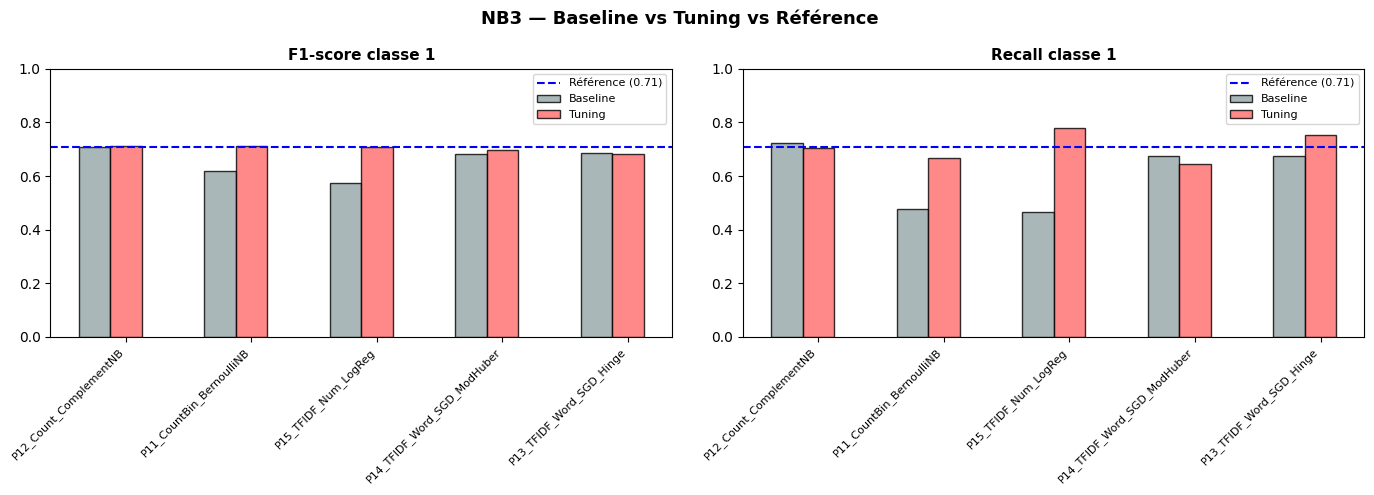

In [10]:
# ── COMPARAISON BASELINE VS TUNING ───────────────────────────────────────────
comparison = []

for _, baseline_row in baseline_df.iterrows():
    tuned_row = tuned_df[tuned_df['pipeline'] == baseline_row['pipeline']].iloc[0]
    comparison.append({
        'pipeline'            : baseline_row['pipeline'],
        'baseline_f1_class_1' : baseline_row['test_f1_class_1'],
        'tuned_f1_class_1'    : tuned_row['test_f1_class_1'],
        'delta_f1_class_1'    : tuned_row['test_f1_class_1'] - baseline_row['test_f1_class_1'],
        'baseline_recall'     : baseline_row['test_recall_class_1'],
        'tuned_recall'        : tuned_row['test_recall_class_1'],
        'delta_recall'        : tuned_row['test_recall_class_1'] - baseline_row['test_recall_class_1'],
        'vs_reference'        : tuned_row['test_f1_class_1'] - REFERENCE_F1,
        'best_params'         : tuned_row['best_params'],
    })

comparison_df = pd.DataFrame(comparison).round(3)
comparison_df = comparison_df.sort_values('tuned_f1_class_1', ascending=False)

print("=== Comparaison Baseline vs Tuning NB3 ===")
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = range(len(comparison_df))
width = 0.25

for ax, metric_base, metric_tuned, title in zip(
    axes,
    ['baseline_f1_class_1', 'baseline_recall'],
    ['tuned_f1_class_1', 'tuned_recall'],
    ['F1-score classe 1', 'Recall classe 1']
):
    ax.bar([i - width for i in x], comparison_df[metric_base],
           width, label='Baseline', color='#95A5A6', edgecolor='black', alpha=0.8)
    ax.bar([i for i in x], comparison_df[metric_tuned],
           width, label='Tuning', color='#FF6B6B', edgecolor='black', alpha=0.8)
    ax.axhline(REFERENCE_F1, color='blue', linestyle='--',
               linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df['pipeline'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('NB3 — Baseline vs Tuning vs Référence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── SAUVEGARDE DES RÉSULTATS ──────────────────────────────────────────────────
baseline_df.to_csv('/kaggle/working/NB3_baseline_results.csv', index=False)
tuned_df.to_csv('/kaggle/working/NB3_tuned_results.csv', index=False)
comparison_df.to_csv('/kaggle/working/NB3_comparison_results.csv', index=False)

print("✅ Résultats sauvegardés :")
print("   → /kaggle/working/NB3_baseline_results.csv")
print("   → /kaggle/working/NB3_tuned_results.csv")
print("   → /kaggle/working/NB3_comparison_results.csv")

print(f"\nMeilleur pipeline NB3 (tuning) : {tuned_df.iloc[0]['pipeline']}")
print(f"F1 classe 1     : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
print(f"Recall classe 1 : {tuned_df.iloc[0]['test_recall_class_1']:.3f}")
print(f"Meilleurs paramètres : {tuned_df.iloc[0]['best_params']}")
print(f"\nComparaison avec référence :")
print(f"Référence F1 : {REFERENCE_F1:.3f}")
print(f"NB3 F1       : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
delta = tuned_df.iloc[0]['test_f1_class_1'] - REFERENCE_F1
print(f"Delta        : {delta:+.3f} {'🟢' if delta > 0 else '🔴'}")

✅ Résultats sauvegardés :
   → /kaggle/working/NB3_baseline_results.csv
   → /kaggle/working/NB3_tuned_results.csv
   → /kaggle/working/NB3_comparison_results.csv

Meilleur pipeline NB3 (tuning) : P12_Count_ComplementNB
F1 classe 1     : 0.712
Recall classe 1 : 0.704
Meilleurs paramètres : {"clf__alpha": 0.5, "clf__norm": true}

Comparaison avec référence :
Référence F1 : 0.710
NB3 F1       : 0.712
Delta        : +0.002 🟢
